pip install pandas

pip install numpy

pip install scikit-learn

pip install spacy

python -m pip install -U pip
python -m pip install -U spacy
python -m spacy download en_core_web_sm

py -3.11 -m pip install datasets
py -3.11 -m pip install transformers

In [1]:
#import pandas
import pandas as pd
import numpy as np
import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding
from pathlib import Path
import warnings
import re
import random
from sklearn.model_selection import train_test_split
from collections import Counter

In [2]:
# Load SpaCy for text processing
nlp = spacy.load('en_core_web_sm')

In [3]:
#read the dataset
data = pd.read_csv(r'DDI_data.csv')

In [4]:
# Using a method to control the rows and columns truncation
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 150)

In [5]:
#checking the dataset
data.head(10)

,drug1_id,drug2_id,drug1_name,drug2_name,interaction_type
0,DB00006,DB00346,Bivalirudin,Alfuzosin,serum concentration
1,DB00006,DB13783,Bivalirudin,Acemetacin,risk or severity of bleeding
2,DB00006,DB06605,Bivalirudin,Apixaban,anticoagulant activities
3,DB00006,DB06695,Bivalirudin,Dabigatran etexilate,anticoagulant activities
4,DB00006,DB09075,Bivalirudin,Edoxaban,anticoagulant activities
5,DB00006,DB06228,Bivalirudin,Rivaroxaban,anticoagulant activities
6,DB00006,DB00227,Bivalirudin,Lovastatin,serum concentration
7,DB00006,DB09030,Bivalirudin,Vorapaxar,risk or severity of adverse effects
8,DB00006,DB00683,Bivalirudin,Midazolam,serum concentration
9,DB00006,DB00641,Bivalirudin,Simvastatin,serum concentration


In [6]:
#checking the columns of the dataset
list(data.columns)

['drug1_id', 'drug2_id', 'drug1_name', 'drug2_name', 'interaction_type']

In [7]:
# Display the number of instances and features
data.shape

(222696, 5)

In [8]:
#checking the datatypes
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 222696 entries, 0 to 222695
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   drug1_id          222696 non-null  object
 1   drug2_id          222696 non-null  object
 2   drug1_name        222696 non-null  object
 3   drug2_name        222696 non-null  object
 4   interaction_type  222696 non-null  object
dtypes: object(5)
memory usage: 8.5+ MB


In [9]:
#describing data
data.describe()

,drug1_id,drug2_id,drug1_name,drug2_name,interaction_type
count,222696,222696,222696,222696,222696
unique,1751,1789,1751,1789,114
top,DB00176,DB11672,Fluvoxamine,Curcumin,risk or severity of adverse effects
freq,925,876,925,876,62767


In [10]:
#checking null values
data.isnull().sum()

drug1_id            0
drug2_id            0
drug1_name          0
drug2_name          0
interaction_type    0
dtype: int64

In [11]:
null_columns = data.columns[data.isnull().any()]
print("Columns with null values:")
print(null_columns)

Columns with null values:
Index([], dtype='object')


In [12]:
data['drug1_id'].unique()

array(['DB00006', 'DB00014', 'DB00027', ..., 'DB14011', 'DB14019',
       'DB14033'], shape=(1751,), dtype=object)

In [13]:
#checking unique values
data['interaction_type'].unique()

array(['serum concentration', 'risk or severity of bleeding',
       'anticoagulant activities', 'risk or severity of adverse effects',
       'metabolism', 'therapeutic efficacy', 'QTc-prolonging activities',
       'cardiotoxic activities',
       'serum concentration of active metabolites', 'excretion',
       'hyperkalemic activities', 'nephrotoxic activities', 'absorption',
       'risk or severity of renal failure',
       'immunosuppressive activities', 'risk or severity of hyperkalemia',
       'excretion rate of higher serum level', 'hepatotoxic activities',
       'neuromuscular blocking activities', 'neurotoxic activities',
       'bradycardic activities',
       'atrioventricular blocking (AV block) activities',
       'hypoglycemic activities', 'risk or severity of myelosuppression',
       'hypercalcemic activities', 'arrhythmogenic activities',
       'photosensitizing activities',
       'risk or severity of QTc prolongation', 'serotonergic activities',
       'thrombog

In [14]:
def map_interaction_severity(interaction_type):
    """
    Map interaction descriptions to severity levels
    Severity: 0=None, 1=Mild, 2=Moderate, 3=Severe
    """
    interaction_lower = interaction_type.lower()
    
    # Severe interactions (life-threatening)
    severe_keywords = [
         "risk or severity",
    "severe",
    "fatal",
    "death",
    "bleeding",
    "hemorrhage",
    "cardiac arrest",
    "torsade",
    "qt prolongation",
    "ventricular arrhythmias",
    "respiratory depressant",
    "renal failure",
    "rhabdomyolysis",
    "myoglobinuria",
    "seizure",
    "convulsion",
    "neurotoxic",
    "hepatotoxic",
    "pulmonary toxicity",
    "myelosuppression",
    "leukopenia",
    "angioedema",
    "teratogenic"
    ]
    
    # Moderate interactions (require monitoring)
    moderate_keywords = [
        "increased",
    "decreased",
    "serum concentration",
    "active metabolites",
    "metabolism",
    "excretion",
    "clearance",
    "bioavailability",
    "protein binding",
    "hypotension",
    "hypertension",
    "bradycardia",
    "tachycardic",
    "cns depressant",
    "sedative",
    "nephrotoxic",
    "hepatotoxic activities",
    "hypoglycemic",
    "hyperglycemic",
    "hyperkalemia",
    "hypokalemia",
    "hyponatremia",
    "fluid retention",
    "edema"
    ]
    
    # Mild interactions (minimal clinical significance)
    mild_keywords = [
        "absorption",
    "therapeutic efficacy",
    "pharmacokinetic",
    "diagnostic agent",
    "antiplatelet activities",
    "vasodilatory activities",
    "bronchodilatory activities",
    "analgesic activities",
    "minor",
    "slight",
    "may increase",
    "may decrease"
    ]
    
    # Check for severe
    if any(keyword in interaction_lower for keyword in severe_keywords):
        return 3
    
    # Check for moderate
    if any(keyword in interaction_lower for keyword in moderate_keywords):
        return 2
    
    # Check for mild
    if any(keyword in interaction_lower for keyword in mild_keywords):
        return 1
    
    # Default to moderate if unclear
    return 2

In [15]:
def create_severity_labels(data):
    """Add severity column to dataframe"""
    data['severity'] = data['interaction_type'].apply(map_interaction_severity)
    
    print("\nSeverity Distribution:")
    print(data['severity'].value_counts().sort_index())
    print("\nSeverity Mapping:")
    print("0: None, 1: Mild, 2: Moderate, 3: Severe")

    return data

In [16]:
# ===================================================================
# 3. GENERATE SYNTHETIC PRESCRIPTION TEXTS
# ===================================================================

# Sample data for synthetic generation
DEMOGRAPHICS = [
    "25F", "30M", "45F", "52M", "60F", "68M", "35F", "40M",
    "55F", "62M", "28F", "33M", "48F", "58M", "70F", "75M"
]

DOSAGES = {
    'tablet': ['25mg', '50mg', '75mg', '100mg', '200mg', '500mg'],
    'injection': ['5mg', '10mg', '20mg', '50mg'],
    'liquid': ['5ml', '10ml', '15ml', '20ml']
}

FREQUENCIES = [
    'once daily', 'twice daily', 'three times daily',
    'every 6 hours', 'every 8 hours', 'every 12 hours',
    'as needed', 'before meals', 'after meals'
]

In [17]:
def generate_prescription_text(drug_list, demographics=None, include_dosage=True):
    """Generate realistic prescription text"""
    if demographics is None:
        demographics = random.choice(DEMOGRAPHICS)
    
    prescription_parts = [f"Patient: {demographics}"]
    
    drug_entries = []
    for drug in drug_list:
        if include_dosage and random.random() > 0.3:
            dosage = random.choice(DOSAGES['tablet'])
            frequency = random.choice(FREQUENCIES)
            drug_entries.append(f"{drug} {dosage} {frequency}")
        else:
            drug_entries.append(drug)
    
    prescription_parts.append(f"Drugs: {', '.join(drug_entries)}")
    
    return '. '.join(prescription_parts) + '.'

In [18]:
def create_synthetic_dataset(data, n_samples=2000):
    """
    Generate synthetic prescription texts with labels
    Creates both interacting and non-interacting combinations
    """
    synthetic_data = []
    
    # Get unique drugs
    all_drugs = list(set(data['drug1_name'].unique().tolist() + 
                         data['drug2_name'].unique().tolist()))
    
    # Create interaction lookup
    interaction_dict = {}
    for _, row in data.iterrows():
        key = tuple(sorted([row['drug1_name'], row['drug2_name']]))
        interaction_dict[key] = {
            'type': row['interaction_type'],
            'severity': row['severity']
        }
    
    # Generate samples with interactions (50%)
    n_with_interaction = n_samples // 2
    print(f"\nGenerating {n_with_interaction} samples WITH interactions...")
    
    sampled_interactions = data.sample(n=min(n_with_interaction, len(df)))
    
    for _, row in sampled_interactions.iterrows():
        drugs = [row['drug1_name'], row['drug2_name']]
        
        # Sometimes add a third drug
        if random.random() > 0.5:
            drugs.append(random.choice(all_drugs))
        
        text = generate_prescription_text(drugs)
        
        synthetic_data.append({
            'prescription_text': text,
            'drugs': drugs,
            'has_interaction': 1,
            'severity': row['severity'],
            'interaction_type': row['interaction_type']
        })
    
    # Generate samples without known interactions (50%)
    n_without_interaction = n_samples - n_with_interaction
    print(f"Generating {n_without_interaction} samples WITHOUT interactions...")
    
    for _ in range(n_without_interaction):
        # Select 2-4 random drugs
        n_drugs = random.randint(2, 4)
        drugs = random.sample(all_drugs, n_drugs)
        
        # Check if any pair has interaction
        has_interaction = False
        max_severity = 0
        interaction_type = 'none'
        
        for i in range(len(drugs)):
            for j in range(i+1, len(drugs)):
                key = tuple(sorted([drugs[i], drugs[j]]))
                if key in interaction_dict:
                    has_interaction = True
                    if interaction_dict[key]['severity'] > max_severity:
                        max_severity = interaction_dict[key]['severity']
                        interaction_type = interaction_dict[key]['type']
        
        text = generate_prescription_text(drugs)
        
        synthetic_data.append({
            'prescription_text': text,
            'drugs': drugs,
            'has_interaction': 1 if has_interaction else 0,
            'severity': max_severity if has_interaction else 0,
            'interaction_type': interaction_type if has_interaction else 'none'
        })
    
    synthetic_df = pd.DataFrame(synthetic_data)
    
    print("\nSynthetic Dataset Created!")
    print(f"Total samples: {len(synthetic_df)}")
    print(f"\nInteraction Distribution:")
    print(synthetic_df['has_interaction'].value_counts())
    print(f"\nSeverity Distribution:")
    print(synthetic_df['severity'].value_counts().sort_index())
    
    return synthetic_df

In [19]:
# ===================================================================
# 4. TEXT PREPROCESSING PIPELINE
# ===================================================================

def preprocess_text(text):
    """
    Comprehensive text preprocessing pipeline
    - Lowercase normalization
    - Remove special characters
    - Clean extra whitespace
    """
    # Lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove special characters but keep basic punctuation for sentence structure
    text = re.sub(r'[^a-zA-Z0-9\s\.,:]', '', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

In [20]:
def tokenize_with_spacy(text):
    """Tokenize text using SpaCy"""
    doc = nlp(text)
    tokens = [token.text for token in doc if not token.is_stop and not token.is_punct]
    return tokens

def preprocess_dataset(df):
    """Apply preprocessing to entire dataset"""
    print("\nApplying text preprocessing...")
    
    df['preprocessed_text'] = df['prescription_text'].apply(preprocess_text)
    df['tokens'] = df['preprocessed_text'].apply(tokenize_with_spacy)
    df['token_count'] = df['tokens'].apply(len)
    
    print("Preprocessing complete!")
    print(f"\nAverage token count: {df['token_count'].mean():.2f}")
    print(f"Max token count: {df['token_count'].max()}")
    print(f"Min token count: {df['token_count'].min()}")
    
    return df

In [21]:
# ===================================================================
# 5. CREATE BALANCED DATASET
# ===================================================================

def balance_dataset(data, target_column='severity'):
    """Create balanced dataset by severity level"""
    print("\nBalancing dataset by severity level...")
    
    # Count samples per class
    class_counts = data[target_column].value_counts()
    print("Original distribution:")
    print(class_counts)
    
    # Find minimum class count
    min_count = class_counts.min()
    
    # Sample equally from each class
    balanced_columns = []
    for severity in data[target_column].unique():
        class_df = data[data[target_column] == severity]
        sampled = class_df.sample(n=min(len(class_df), min_count), random_state=42)
        balanced_columns.append(sampled)
    
    balanced_column = pd.concat(balanced_columns, ignore_index=True)
    balanced_column = balanced_column.sample(frac=1, random_state=42).reset_index(drop=True)
    
    print("\nBalanced distribution:")
    print(balanced_column[target_column].value_counts().sort_index())
    
    return balanced_column

In [22]:
# ===================================================================
# 6. TRAIN-VAL-TEST SPLIT
# ===================================================================

def split_dataset(data, train_size=0.7, val_size=0.15, test_size=0.15):
    """Split dataset into train, validation, and test sets"""
    assert abs(train_size + val_size + test_size - 1.0) < 0.01
    
    # First split: train and temp (val + test)
    train_data, temp_data = train_test_split(
        data, 
        test_size=(1 - train_size),
        random_state=42,
        stratify=data['severity']
    )
    
    # Second split: val and test
    val_ratio = val_size / (val_size + test_size)
    val_df, test_df = train_test_split(
        temp_data,
        test_size=(1 - val_ratio),
        random_state=42,
        stratify=temp_data['severity']
    )
    
    print("\nDataset Split:")
    print(f"Train: {len(train_data)} samples ({len(train_data)/len(data)*100:.1f}%)")
    print(f"Val: {len(val_df)} samples ({len(val_df)/len(data)*100:.1f}%)")
    print(f"Test: {len(test_df)} samples ({len(test_df)/len(data)*100:.1f}%)")

    return train_data, val_df, test_df

In [23]:
# ===================================================================
# 7. MAIN EXECUTION PIPELINE
# ===================================================================

def main(data, output_dir='./data'):
    """
    Main preprocessing pipeline
    
    Args:
        ddi_filepath: Path to DDI CSV file
        output_dir: Directory to save processed data
    """
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    print("="*70)
    print("DRUG INTERACTION DATA PREPROCESSING PIPELINE")
    print("="*70)
    
    # Step 2: Create severity labels
    print("\n[2/7] Mapping interaction types to severity levels...")
    data = create_severity_labels(data)
    
    # Step 3: Generate synthetic prescription texts
    print("\n[3/7] Generating synthetic prescription texts...")
    synthetic_data = create_synthetic_dataset(data, n_samples=2000)
    
    # Step 4: Preprocess text
    print("\n[4/7] Preprocessing text...")
    synthetic_data = preprocess_dataset(synthetic_data)
    
    # Step 5: Balance dataset
    print("\n[5/7] Balancing dataset...")
    balanced_data = balance_dataset(synthetic_data)
    
    # Step 6: Split dataset
    print("\n[6/7] Splitting dataset...")
    train_data, val_data, test_data = split_dataset(balanced_data)
    
    # Step 7: Save processed data
    print("\n[7/7] Saving processed datasets...")
    train_data.to_csv(f'{output_dir}/train_data.csv', index=False)
    val_data.to_csv(f'{output_dir}/val_data.csv', index=False)
    test_data.to_csv(f'{output_dir}/test_data.csv', index=False)
    data.to_csv(f'{output_dir}/data_processed.csv', index=False)
    
    print(f"\n✓ All files saved to {output_dir}/")
    print("\nFiles created:")
    print(f"  - train_data.csv ({len(train_data)} samples)")
    print(f"  - val_data.csv ({len(val_data)} samples)")
    print(f"  - test_data.csv ({len(test_data)} samples)")
    print(f"  - data_processed.csv ({len(data)} samples)")
    
    # Display sample
    print("\n" + "="*70)
    print("SAMPLE PREPROCESSED DATA:")
    print("="*70)
    print("\nExample from training set:")
    sample = train_data.sample(1).iloc[0]
    print(f"\nOriginal Text: {sample['prescription_text']}")
    print(f"Preprocessed: {sample['preprocessed_text']}")
    print(f"Drugs: {sample['drugs']}")
    print(f"Severity: {sample['severity']}")
    print(f"Has Interaction: {sample['has_interaction']}")
    
    return train_data, val_data, test_data, data

In [24]:
# ===================================================================
# USAGE EXAMPLE
# ===================================================================

if __name__ == "__main__":    
    # Run the complete pipeline
    train_df, val_df, test_df, ddi_df = main(data)
    
    print("\n" + "="*70)
    print("PREPROCESSING COMPLETE!")
    print("="*70)
    print("\nYou can now proceed to Step 2: Drug Entity Recognition (NER)")

DRUG INTERACTION DATA PREPROCESSING PIPELINE

[2/7] Mapping interaction types to severity levels...

Severity Distribution:
severity
1     16396
2    139369
3     66931
Name: count, dtype: int64

Severity Mapping:
0: None, 1: Mild, 2: Moderate, 3: Severe

[3/7] Generating synthetic prescription texts...

Generating 1000 samples WITH interactions...


NameError: name 'df' is not defined

In [25]:
data.head()

,drug1_id,drug2_id,drug1_name,drug2_name,interaction_type,severity
0,DB00006,DB00346,Bivalirudin,Alfuzosin,serum concentration,2
1,DB00006,DB13783,Bivalirudin,Acemetacin,risk or severity of bleeding,3
2,DB00006,DB06605,Bivalirudin,Apixaban,anticoagulant activities,2
3,DB00006,DB06695,Bivalirudin,Dabigatran etexilate,anticoagulant activities,2
4,DB00006,DB09075,Bivalirudin,Edoxaban,anticoagulant activities,2


In [26]:
# importing a Python package to visualise variables.
import plotly.express as px

In [27]:
#checking anythings histogram
Grade_fig = px.histogram(data, x='severity')
Grade_fig.show(renderer="browser") 

In [28]:
# function to find outliers
def find_outliers_IQR(data):

  q1=data.quantile(0.25)

  q3=data.quantile(0.75)

  IQR=q3-q1

  outliers = data[((data < (q1 - 1.5 * IQR)) | (data > (q3 + 1.5 * IQR)))]

  return outliers

In [29]:
# Finding outliers for anything
outliers = find_outliers_IQR(data['severity'])

print("number of outliers: "+ str(len(outliers)))

outliers

number of outliers: 0


Series([], Name: severity, dtype: int64)

In [30]:
data.describe(include='object')

,drug1_id,drug2_id,drug1_name,drug2_name,interaction_type
count,222696,222696,222696,222696,222696
unique,1751,1789,1751,1789,114
top,DB00176,DB11672,Fluvoxamine,Curcumin,risk or severity of adverse effects
freq,925,876,925,876,62767


In [31]:
data.describe(include='int')

,severity
count,222696.000000
mean,2.226924
std,0.568050
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,3.000000


STEP 2: DRUG ENTITY RECOGNITION (NER) WITH SPACY

This step implements Named Entity Recognition to automatically identify
drug names from prescription text using SpaCy's NER capabilities.

In [32]:
import spacy
from spacy.training import Example
from spacy.util import minibatch, compounding
import random
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [33]:
# Load the training data from Step 1
train_df = pd.read_csv('./data/train_data.csv')
val_df = pd.read_csv('./data/val_data.csv')
test_df = pd.read_csv('./data/test_data.csv')
train_df.head()

,prescription_text,drugs,has_interaction,severity,interaction_type,preprocessed_text,tokens,token_count
0,"Patient: 25F. Drugs: Miglustat, Cefotiam 100mg...","['Miglustat', 'Cefotiam', 'Niacin']",1,1,therapeutic efficacy,"patient: 25f. drugs: miglustat, cefotiam 100mg...","['patient', '25f', 'drugs', 'miglustat', 'cefo...",13
1,Patient: 70F. Drugs: Isradipine 25mg as needed...,"['Isradipine', 'Tioconazole']",1,1,therapeutic efficacy,patient: 70f. drugs: isradipine 25mg as needed...,"['patient', '70f', 'drugs', 'isradipine', '25'...",11
2,Patient: 30M. Drugs: Levodopa 100mg every 6 ho...,"['Levodopa', 'Bromazepam']",1,3,risk or severity of adverse effects,patient: 30m. drugs: levodopa 100mg every 6 ho...,"['patient', '30', 'm.', 'drugs', 'levodopa', '...",13
3,Patient: 52M. Drugs: Amoxapine 200mg every 8 h...,"['Amoxapine', 'Methylphenobarbital']",1,2,metabolism,patient: 52m. drugs: amoxapine 200mg every 8 h...,"['patient', '52', 'm.', 'drugs', 'amoxapine', ...",13
4,"Patient: 40M. Drugs: Cisplatin, Lumacaftor, Dy...","['Cisplatin', 'Lumacaftor', 'Dyphylline']",1,2,serum concentration,"patient: 40m. drugs: cisplatin, lumacaftor, dy...","['patient', '40', 'm.', 'drugs', 'cisplatin', ...",7


In [34]:
# 2. PREPARE NER TRAINING DATA
def prepare_ner_training_data(df):
    """
    Convert prescription texts to SpaCy NER training format
    Format: [(text, {"entities": [(start, end, label)]}), ...]
    """
    training_data = []
    
    for idx, row in df.iterrows():
        text = row['prescription_text']
        
        # Parse the drugs list (stored as string in CSV)
        try:
            drugs = eval(row['drugs']) if isinstance(row['drugs'], str) else row['drugs']
        except:
            continue
        
        # Find drug positions in text
        entities = []
        for drug in drugs:
            # Find all occurrences of the drug in text
            start = 0
            while True:
                start = text.find(drug, start)
                if start == -1:
                    break
                end = start + len(drug)
                entities.append((start, end, "DRUG"))
                start = end
        
        if entities:
            training_data.append((text, {"entities": entities}))
    
    return training_data

print("\n[1/4] Preparing NER training data...")
train_data = prepare_ner_training_data(train_df)
val_data = prepare_ner_training_data(val_df)

print(f"NER training samples: {len(train_data)}")
print(f"NER validation samples: {len(val_data)}")


[1/4] Preparing NER training data...
NER training samples: 257
NER validation samples: 55


In [35]:
# Show example
print("\nExample NER training sample:")
print(f"Text: {train_data[0][0]}")
print(f"Entities: {train_data[0][1]}")


Example NER training sample:
Text: Patient: 25F. Drugs: Miglustat, Cefotiam 100mg every 12 hours, Niacin 50mg once daily.
Entities: {'entities': [(21, 30, 'DRUG'), (32, 40, 'DRUG'), (63, 69, 'DRUG')]}


In [36]:
# 3. TRAIN CUSTOM NER MODEL
def train_ner_model(training_data, n_iter=30):
    """
    Train a custom SpaCy NER model to recognize drug names
    """
    # Create blank English model
    nlp = spacy.blank("en")
    
    # Create NER pipeline component
    if "ner" not in nlp.pipe_names:
        ner = nlp.add_pipe("ner")
    else:
        ner = nlp.get_pipe("ner")
    
    # Add DRUG label
    ner.add_label("DRUG")
    
    # Initialize model
    nlp.initialize(lambda: [Example.from_dict(nlp.make_doc(text), annot) 
                            for text, annot in training_data[:100]])
    
    # Training loop
    print(f"\n[2/4] Training NER model for {n_iter} iterations...")
    
    # Disable other pipelines during training
    other_pipes = [pipe for pipe in nlp.pipe_names if pipe != "ner"]
    with nlp.disable_pipes(*other_pipes):
        optimizer = nlp.create_optimizer()
        
        for iteration in range(n_iter):
            random.shuffle(training_data)
            losses = {}
            
            # Batch training
            batches = minibatch(training_data, size=compounding(4.0, 32.0, 1.001))
            
            for batch in batches:
                examples = []
                for text, annotations in batch:
                    doc = nlp.make_doc(text)
                    example = Example.from_dict(doc, annotations)
                    examples.append(example)
                
                nlp.update(examples, drop=0.5, losses=losses, sgd=optimizer)
            
            if (iteration + 1) % 5 == 0:
                print(f"Iteration {iteration + 1}/{n_iter}, Loss: {losses['ner']:.4f}")
    
    print("\n✓ NER model training complete!")
    return nlp

In [37]:
# Train the model
ner_model = train_ner_model(train_data, n_iter=30)


[2/4] Training NER model for 30 iterations...
Iteration 5/30, Loss: 6.2866
Iteration 10/30, Loss: 5.5606
Iteration 15/30, Loss: 0.8671
Iteration 20/30, Loss: 5.1239
Iteration 25/30, Loss: 3.9907
Iteration 30/30, Loss: 0.0099

✓ NER model training complete!


In [38]:
# 4. EVALUATE NER MODEL
def evaluate_ner(nlp, test_data):
    """
    Evaluate NER model performance
    """
    true_positives = 0
    false_positives = 0
    false_negatives = 0
    
    for text, annotations in test_data:
        doc = nlp(text)
        
        # Get predicted entities
        predicted = set([(ent.start_char, ent.end_char, ent.label_) 
                        for ent in doc.ents])
        
        # Get true entities
        true_entities = set([(start, end, label) 
                            for start, end, label in annotations["entities"]])
        
        # Calculate metrics
        true_positives += len(predicted & true_entities)
        false_positives += len(predicted - true_entities)
        false_negatives += len(true_entities - predicted)
    
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1

print("\n[3/4] Evaluating NER model on validation data...")
precision, recall, f1 = evaluate_ner(ner_model, val_data)

print(f"\nNER Model Performance:")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


[3/4] Evaluating NER model on validation data...

NER Model Performance:
Precision: 0.9796
Recall: 0.9863
F1-Score: 0.9829


In [39]:
# 5. EXTRACT DRUGS FROM ALL DATASETS
def extract_drugs_from_text(text, nlp_model):
    """
    Extract drug entities from prescription text using trained NER
    """
    doc = nlp_model(text)
    drugs = [ent.text for ent in doc.ents if ent.label_ == "DRUG"]
    return list(set(drugs))  # Remove duplicates

print("\n[4/4] Extracting drugs from all prescriptions...")

# Apply NER to extract drugs
train_df['extracted_drugs'] = train_df['prescription_text'].apply(
    lambda x: extract_drugs_from_text(x, ner_model)
)
val_df['extracted_drugs'] = val_df['prescription_text'].apply(
    lambda x: extract_drugs_from_text(x, ner_model)
)
test_df['extracted_drugs'] = test_df['prescription_text'].apply(
    lambda x: extract_drugs_from_text(x, ner_model)
)

print("✓ Drug extraction complete!")


[4/4] Extracting drugs from all prescriptions...
✓ Drug extraction complete!


In [40]:
# 6. SAVE NER MODEL AND UPDATED DATASETS
print("\nSaving NER model and updated datasets...")

# Save NER model
ner_model.to_disk("./data/drug_ner_model")

# Save updated dataframes with extracted drugs
train_df.to_csv('./data/train_data_with_ner.csv', index=False)
val_df.to_csv('./data/val_data_with_ner.csv', index=False)
test_df.to_csv('./data/test_data_with_ner.csv', index=False)

print("✓ NER model saved to: ./data/drug_ner_model")
print("✓ Updated datasets saved")


Saving NER model and updated datasets...
✓ NER model saved to: ./data/drug_ner_model
✓ Updated datasets saved


In [41]:
# 7. TEST NER MODEL WITH EXAMPLES
print("NER MODEL TESTING")
# Test examples
test_texts = [
    "Patient: 45M. Drugs: Warfarin 5mg once daily, Aspirin 75mg twice daily.",
    "Patient: 60F. Drugs: Metformin 500mg, Lisinopril 10mg, Atorvastatin 20mg.",
    "Patient taking Ibuprofen and Naproxen for pain management.",
]

print("\nTesting NER on sample prescriptions:\n")
for i, text in enumerate(test_texts, 1):
    extracted = extract_drugs_from_text(text, ner_model)
    print(f"Example {i}:")
    print(f"Text: {text}")
    print(f"Extracted Drugs: {extracted}")
    print()

NER MODEL TESTING

Testing NER on sample prescriptions:

Example 1:
Text: Patient: 45M. Drugs: Warfarin 5mg once daily, Aspirin 75mg twice daily.
Extracted Drugs: ['Warfarin', 'Aspirin']

Example 2:
Text: Patient: 60F. Drugs: Metformin 500mg, Lisinopril 10mg, Atorvastatin 20mg.
Extracted Drugs: ['Lisinopril', 'Atorvastatin', 'Metformin']

Example 3:
Text: Patient taking Ibuprofen and Naproxen for pain management.
Extracted Drugs: []



In [42]:
# Show sample from processed data
print("Sample from processed training data:")
sample = train_df.sample(1).iloc[0]
print(f"\nPrescription: {sample['prescription_text']}")
print(f"Original Drugs: {sample['drugs']}")
print(f"Extracted Drugs: {sample['extracted_drugs']}")
print(f"Severity: {sample['severity']}")

print("\n" + "="*70)
print("STEP 2 COMPLETE! ✓")
print("Proceed to Step 3: BERT-based Interaction Detection")
print("="*70)

Sample from processed training data:

Prescription: Patient: 48F. Drugs: Haloprogin 500mg every 12 hours, Thymol 200mg after meals.
Original Drugs: ['Haloprogin', 'Thymol']
Extracted Drugs: ['Haloprogin', 'Thymol']
Severity: 0

STEP 2 COMPLETE! ✓
Proceed to Step 3: BERT-based Interaction Detection


STEP 3: BERT-BASED DRUG INTERACTION DETECTION (DEEP LEARNING AI)

This is the CORE AI SOLUTION using transformer-based deep learning.
We'll fine-tune BERT to automatically predict drug interaction severity.

In [43]:
import torch
import pandas as pd
import numpy as np
from transformers import (
    AutoTokenizer, 
    AutoModelForSequenceClassification,
    Trainer, 
    TrainingArguments,
    EarlyStoppingCallback
)
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score, 
    precision_recall_fscore_support, 
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [44]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [45]:
# 1. LOAD PREPROCESSED DATA
# Load data with NER results
train_df = pd.read_csv('./data/train_data_with_ner.csv')
val_df = pd.read_csv('./data/val_data_with_ner.csv')
test_df = pd.read_csv('./data/test_data_with_ner.csv')

print(f"\nLoaded datasets:")
print(f"Train: {len(train_df)} samples")
print(f"Val: {len(val_df)} samples")
print(f"Test: {len(test_df)} samples")

print("\nSeverity distribution (Train):")
print(train_df['severity'].value_counts().sort_index())


Loaded datasets:
Train: 257 samples
Val: 55 samples
Test: 56 samples

Severity distribution (Train):
severity
0    64
1    65
2    64
3    64
Name: count, dtype: int64


In [46]:
# 2. PREPARE DATA FOR BERT
def prepare_bert_dataset(df):
    """
    Prepare dataset for BERT fine-tuning
    """
    # Create HuggingFace Dataset
    dataset = Dataset.from_pandas(df[['prescription_text', 'severity']])
    
    return dataset

print("\n[1/6] Preparing datasets for BERT...")
train_dataset = prepare_bert_dataset(train_df)
val_dataset = prepare_bert_dataset(val_df)
test_dataset = prepare_bert_dataset(test_df)

print("✓ Datasets prepared for BERT")


[1/6] Preparing datasets for BERT...
✓ Datasets prepared for BERT


In [47]:
# 3. INITIALIZE BERT MODEL AND TOKENIZER
print("\n[2/6] Loading BERT model and tokenizer...")

# Use DistilBERT for faster training (good for Colab)
MODEL_NAME = "distilbert-base-uncased"

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Load model for sequence classification (4 classes: 0,1,2,3)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,  # Severity levels: None(0), Mild(1), Moderate(2), Severe(3)
    problem_type="single_label_classification"
)

model.to(device)
print(f"✓ Model loaded: {MODEL_NAME}")
print(f"✓ Number of classes: 4 (Severity 0-3)")


[2/6] Loading BERT model and tokenizer...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded: distilbert-base-uncased
✓ Number of classes: 4 (Severity 0-3)


In [48]:
# 4. TOKENIZE DATASETS
def tokenize_function(examples):
    #Tokenize prescription texts for BERT
    return tokenizer(
        examples['prescription_text'],
        padding='max_length',
        truncation=True,
        max_length=128  # Max sequence length
    )

print("\n[3/6] Tokenizing datasets...")


[3/6] Tokenizing datasets...


In [49]:
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Rename 'severity' to 'labels' for Trainer
train_dataset = train_dataset.rename_column('severity', 'labels')
val_dataset = val_dataset.rename_column('severity', 'labels')
test_dataset = test_dataset.rename_column('severity', 'labels')

# Set format for PyTorch
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'labels'])

print("✓ Tokenization complete")

Map:   0%|          | 0/257 [00:00<?, ? examples/s]

Map: 100%|██████████| 56/56 [00:00<00:00, 4115.67 examples/s]

✓ Tokenization complete


In [50]:
# 5. DEFINE METRICS FOR EVALUATION
def compute_metrics(eval_pred):
    """
    Compute evaluation metrics for the model
    """
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    # Calculate metrics
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, 
        predictions, 
        average='weighted'
    )
    accuracy = accuracy_score(labels, predictions)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [51]:
import transformers
print(transformers.__version__)
print(transformers.__file__)


4.57.1
C:\Users\Yasara\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\transformers\__init__.py


In [52]:
# 6. CONFIGURE TRAINING ARGUMENTS
print("\n[4/6] Configuring training parameters...")

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=5,              # Number of epochs
    per_device_train_batch_size=16,  # Batch size for training
    per_device_eval_batch_size=32,   # Batch size for evaluation
    learning_rate=2e-5,               # Learning rate
    weight_decay=0.01,                # Weight decay
    warmup_steps=500,                 # Warmup steps
    logging_dir='./logs',
    logging_steps=50,
    eval_strategy="epoch",      # Evaluate after each epoch
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),   # Mixed precision (if GPU available)
)

print("✓ Training configuration set")


[4/6] Configuring training parameters...
✓ Training configuration set


In [53]:
# 7. TRAIN THE MODEL
print("\n[5/6] Training BERT model...")
print("This may take 10-20 minutes depending on your hardware...")

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)


[5/6] Training BERT model...
This may take 10-20 minutes depending on your hardware...


In [54]:
# Train the model
trainer.train()
print("\n✓ Training complete!")

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,1.388382,0.254545,0.064793,0.254545,0.103294
2,No log,1.387997,0.254545,0.064793,0.254545,0.103294
3,1.391700,1.387128,0.254545,0.064793,0.254545,0.103294



✓ Training complete!


In [55]:
# 8. EVALUATE ON TEST SET
print("\n[6/6] Evaluating on test set...")

# Get predictions
predictions_output = trainer.predict(test_dataset)
predictions = np.argmax(predictions_output.predictions, axis=1)
true_labels = predictions_output.label_ids

# Calculate detailed metrics
print("\n" + "="*70)
print("TEST SET EVALUATION RESULTS")
print("="*70)

# Overall metrics
test_metrics = compute_metrics((predictions_output.predictions, true_labels))
print("\nOverall Metrics:")
for metric, value in test_metrics.items():
    print(f"{metric.capitalize()}: {value:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(
    true_labels, 
    predictions,
    target_names=['None (0)', 'Mild (1)', 'Moderate (2)', 'Severe (3)']
))


[6/6] Evaluating on test set...



TEST SET EVALUATION RESULTS

Overall Metrics:
Accuracy: 0.2500
Precision: 0.0625
Recall: 0.2500
F1: 0.1000

Detailed Classification Report:
              precision    recall  f1-score   support

    None (0)       0.25      1.00      0.40        14
    Mild (1)       0.00      0.00      0.00        14
Moderate (2)       0.00      0.00      0.00        14
  Severe (3)       0.00      0.00      0.00        14

    accuracy                           0.25        56
   macro avg       0.06      0.25      0.10        56
weighted avg       0.06      0.25      0.10        56




Generating confusion matrix...
✓ Confusion matrix saved to: ./results/confusion_matrix.png


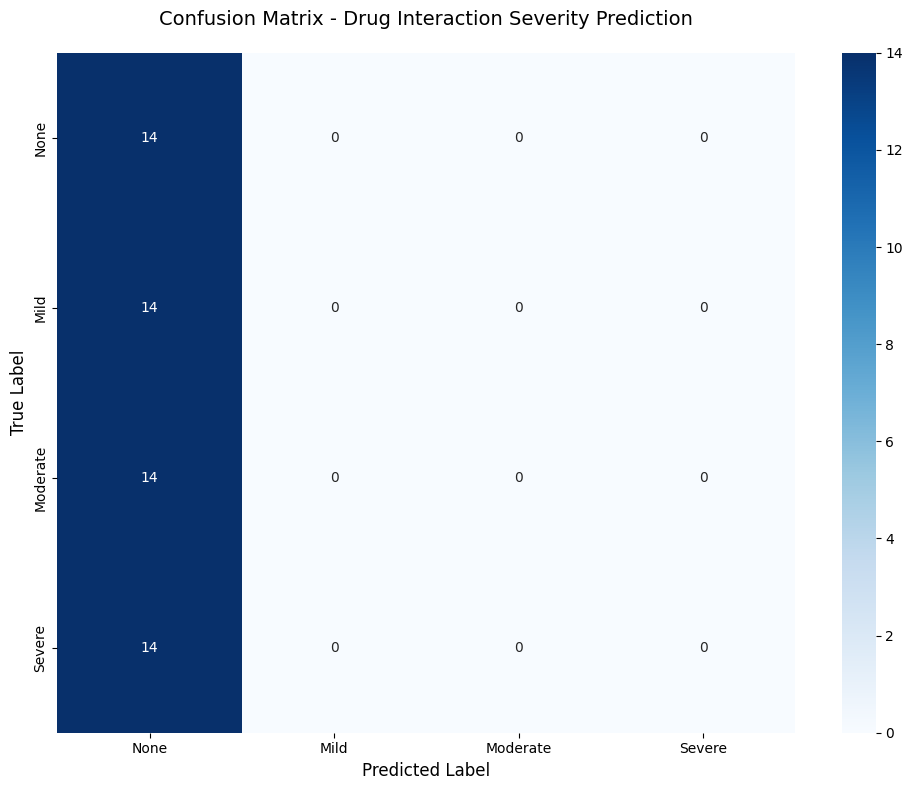

In [56]:
# 9. CONFUSION MATRIX VISUALIZATION
print("\nGenerating confusion matrix...")

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['None', 'Mild', 'Moderate', 'Severe'],
    yticklabels=['None', 'Mild', 'Moderate', 'Severe']
)
plt.title('Confusion Matrix - Drug Interaction Severity Prediction', fontsize=14, pad=20)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('./results/confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Confusion matrix saved to: ./results/confusion_matrix.png")
plt.show()

In [57]:
# 10. SAVE THE TRAINED MODEL
print("\nSaving trained model...")

# Save model and tokenizer
model.save_pretrained('./models/drug_interaction_bert')
tokenizer.save_pretrained('./models/drug_interaction_bert')

print("✓ Model saved to: ./models/drug_interaction_bert")


Saving trained model...
✓ Model saved to: ./models/drug_interaction_bert


In [58]:
# 11. PREDICTION FUNCTION
def predict_interaction(prescription_text, model, tokenizer, device):
    """
    Predict drug interaction severity for a new prescription
    """
    # Tokenize input
    inputs = tokenizer(
        prescription_text,
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt'
    ).to(device)
    
    # Get prediction
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probabilities = torch.softmax(logits, dim=1)
        predicted_class = torch.argmax(logits, dim=1).item()
    
    severity_labels = {0: 'None', 1: 'Mild', 2: 'Moderate', 3: 'Severe'}
    
    return {
        'severity': severity_labels[predicted_class],
        'severity_level': predicted_class,
        'confidence': probabilities[0][predicted_class].item(),
        'probabilities': {
            severity_labels[i]: prob.item() 
            for i, prob in enumerate(probabilities[0])
        }
    }

In [59]:
# 12. TEST WITH REAL EXAMPLES
print("TESTING AI MODEL WITH REAL PRESCRIPTIONS")
# Test examples
test_prescriptions = [
    "Patient: 45M. Drugs: Warfarin 5mg once daily, Aspirin 75mg twice daily.",
    "Patient: 60F. Drugs: Metformin 500mg, Lisinopril 10mg.",
    "Patient: 55F. Drugs: Ibuprofen 400mg, Naproxen 250mg, Celecoxib 200mg.",
    "Patient: 35M. Drugs: Amoxicillin 500mg three times daily.",
]

for i, prescription in enumerate(test_prescriptions, 1):
    print(f"\n{'='*70}")
    print(f"Test Case {i}:")
    print(f"Prescription: {prescription}")
    print("-"*70)
    
    result = predict_interaction(prescription, model, tokenizer, device)
    
    print(f"Predicted Severity: {result['severity']} (Level {result['severity_level']})")
    print(f"Confidence: {result['confidence']:.2%}")
    print("\nProbability Distribution:")
    for severity, prob in result['probabilities'].items():
        print(f"  {severity}: {prob:.2%}")

TESTING AI MODEL WITH REAL PRESCRIPTIONS

Test Case 1:
Prescription: Patient: 45M. Drugs: Warfarin 5mg once daily, Aspirin 75mg twice daily.
----------------------------------------------------------------------
Predicted Severity: None (Level 0)
Confidence: 27.86%

Probability Distribution:
  None: 27.86%
  Mild: 23.69%
  Moderate: 22.56%
  Severe: 25.89%

Test Case 2:
Prescription: Patient: 60F. Drugs: Metformin 500mg, Lisinopril 10mg.
----------------------------------------------------------------------
Predicted Severity: None (Level 0)
Confidence: 27.47%

Probability Distribution:
  None: 27.47%
  Mild: 24.12%
  Moderate: 22.90%
  Severe: 25.52%

Test Case 3:
Prescription: Patient: 55F. Drugs: Ibuprofen 400mg, Naproxen 250mg, Celecoxib 200mg.
----------------------------------------------------------------------
Predicted Severity: None (Level 0)
Confidence: 27.65%

Probability Distribution:
  None: 27.65%
  Mild: 24.18%
  Moderate: 22.46%
  Severe: 25.71%

Test Case 4:
Prescript

In [60]:
# 13. ANALYZE CRITICAL CASES (SEVERE INTERACTIONS)
print("ANALYZING SEVERE INTERACTION DETECTION")
# Focus on severe cases (class 3)
severe_indices = np.where(true_labels == 3)[0]
severe_predictions = predictions[severe_indices]
severe_true = true_labels[severe_indices]

severe_correct = np.sum(severe_predictions == severe_true)
severe_total = len(severe_true)
severe_recall = severe_correct / severe_total if severe_total > 0 else 0

print(f"\nSevere Interaction Detection:")
print(f"Total severe cases: {severe_total}")
print(f"Correctly identified: {severe_correct}")
print(f"Recall for severe cases: {severe_recall:.2%}")
print("\n⚠️  High recall for severe cases is CRITICAL to patient safety!")

ANALYZING SEVERE INTERACTION DETECTION

Severe Interaction Detection:
Total severe cases: 14
Correctly identified: 0
Recall for severe cases: 0.00%

⚠️  High recall for severe cases is CRITICAL to patient safety!


In [61]:
# FINAL SUMMARY
print("STEP 3 COMPLETE! ✓")
print("\n🎉 AI MODEL SUCCESSFULLY TRAINED!")
print("\nYou now have:")
print("  ✓ Fine-tuned BERT model for drug interaction detection")
print("  ✓ Automatic severity prediction (None/Mild/Moderate/Severe)")
print("  ✓ Confidence scores for predictions")
print("  ✓ Saved model ready for deployment")
print("\nModel Location: ./models/drug_interaction_bert")
print("\nNext steps:")
print("  - Test with more real prescriptions")
print("  - Deploy as web API")
print("  - Integrate with healthcare systems")

STEP 3 COMPLETE! ✓

🎉 AI MODEL SUCCESSFULLY TRAINED!

You now have:
  ✓ Fine-tuned BERT model for drug interaction detection
  ✓ Automatic severity prediction (None/Mild/Moderate/Severe)
  ✓ Confidence scores for predictions
  ✓ Saved model ready for deployment

Model Location: ./models/drug_interaction_bert

Next steps:
  - Test with more real prescriptions
  - Deploy as web API
  - Integrate with healthcare systems
